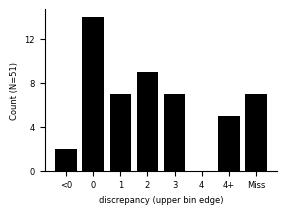

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

labels = ["<0", "0", "1", "2", "3", "4", "4+", "Miss"]
counts = [2, 14, 7, 9, 7, 0, 5, 7]      # <-- your numbers
N = sum(counts)


plt.rcParams["font.size"] = 6

fig, ax = plt.subplots(figsize=(3.0, 2.1))
ax.bar(labels, counts, color="black", edgecolor="none")
ax.set_xlabel("discrepancy (upper bin edge)")
ax.set_ylabel(f"Count (N={N})")

ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
ax.spines[["top", "right"]].set_visible(False)
fig.savefig("Tracking_gem_mask.pdf", bbox_inches="tight")

In [1]:
\begin{table}[t]
\centering
\caption{Detection counts per person across 11 runs, compared against ground truth.}
\label{tab:person_runs}
\resizebox{\textwidth}{!}{%
\begin{tabular}{c c *{11}{c} c c c c}
\toprule
Person & Real & R1 & R2 & R3 & R4 & R5 & R6 & R7 & R8 & R9 & R10 & R11 & Average & \% correct & Runs $\geq$1 hit & \% correct \\
\midrule
1    & 4 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3 & 3.0  & 75\%  & 11 & 100\% \\
2    & 3 & 1 & 1 & 1 & 1 & 1 & 1 & 2 & 1 & 1 & 2 & 1 & 1.2  & 39\%  & 11 & 100\% \\
3    & 3 & 2 & 1 & 1 & 3 & 2 & 1 & 3 & 3 & 1 & 3 & 3 & 2.1  & 70\%  & 11 & 100\% \\
4    & 4 & 2 & 1 & 2 & 3 & 3 & 1 & 3 & 4 & 3 & 1 & 2 & 2.3  & 57\%  & 11 & 100\% \\
5    & 2 & 2 & 3 & 3 & 2 & 2 & 2 & 1 & 2 & 2 & 2 & 1 & 2.0  & 100\% & 11 & 100\% \\
6    & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1.0  & 100\% & 11 & 100\% \\
7    & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 1 & 0 & 1 & 1 & 0.9  & 91\%  & 10 & 91\%  \\
8    & 1 & 0 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 0 & 0 & 0 & 0.4  & 36\%  & 4  & 36\%  \\
\midrule
None & 5 & 12& 13& 12& 10& 10& 13& 10& 7 & 12& 13& 11& 11.2 & 224\% & -- & --   \\
\bottomrule
\end{tabular}%
}
\end{table}


SyntaxError: unexpected character after line continuation character (1486249215.py, line 1)

In [11]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parents[1]  # src/Experiments -> project root

files = [
    project_root / "Data/07_Tropea_cafe/080_Experiments/100m_gps_v3/100m_gps_v3_results.csv",
    project_root / "Data/01_walk/080_Experiments/sweep_inferity/sweep_inferity_results.csv",
    project_root / "Data/01_walk/080_Experiments/sweeps_short_inferity/sweeps_short_inferity_results.csv",
]

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df


,rmse,mean dist,correspondences,cam poses (n),trajectory length (m),spatial_extent,rmse cm/m,runtime (min),n_frames,recon_interframe_interval,technique,cam_poses
0,25.081670,17.201864,7,25,166.596378,47.728987,15.055351,0.351512,25,280,CUT3R,25
1,29.850884,25.556398,7,25,166.596378,47.728987,17.918087,0.312374,25,280,CUT3R_Revisit,25
2,4.821915,4.603617,7,25,166.596378,47.728987,2.894370,0.714819,25,280,lingbot-map,25
3,20.817730,15.309364,7,25,166.596378,47.728987,12.495908,2.013344,25,280,MegaSaM,25
4,14.027455,12.929256,7,25,166.596378,47.728987,8.420024,0.453451,25,280,VGGT,25
...,...,...,...,...,...,...,...,...,...,...,...,...
181,0.972012,0.818100,26,273,102.578517,27.261005,0.947578,13.790497,273,9,MegaSaM,275
182,6.426026,5.346714,26,273,102.578517,27.261005,6.264495,1.206999,273,9,CUT3R,300
183,26.393312,23.454321,26,273,102.578517,27.261005,25.729863,1.942909,273,9,CUT3R_Revisit,300
184,3.093909,2.646202,26,273,102.578517,27.261005,3.016137,1.500880,273,9,lingbot-map,300


In [8]:
out_dir = project_root/"Data"/"FIGS"

# Cam density
## precise sat

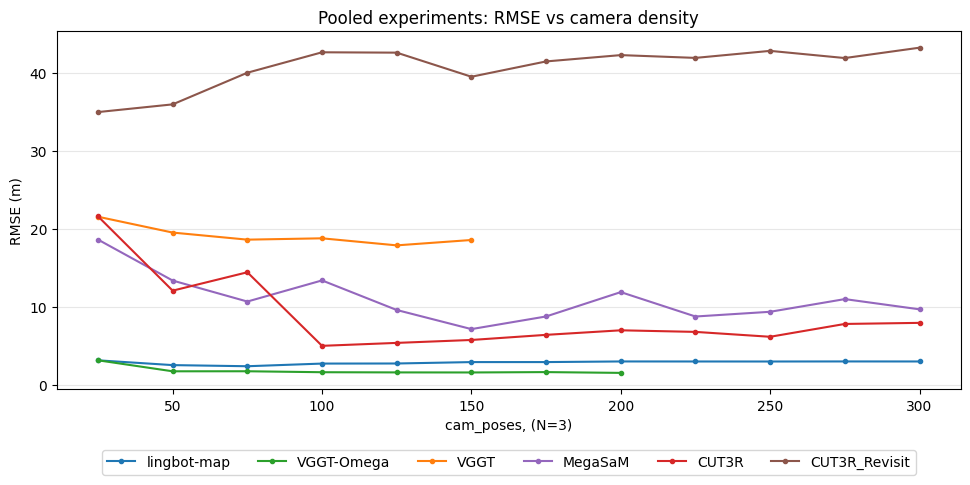

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

runs = [
    ("07_Tropea_cafe", "100m_gps_v3"),
    ("01_walk", "sweep_inferity"),
    ("01_walk", "sweeps_short_inferity"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"], as_index=False)[["rmse", "mean dist"]].mean()

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))



ax.set_xlabel("cam_poses, (N=3)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_density_precise.pdf", format="pdf", bbox_inches="tight")


project_root: /workspace/project


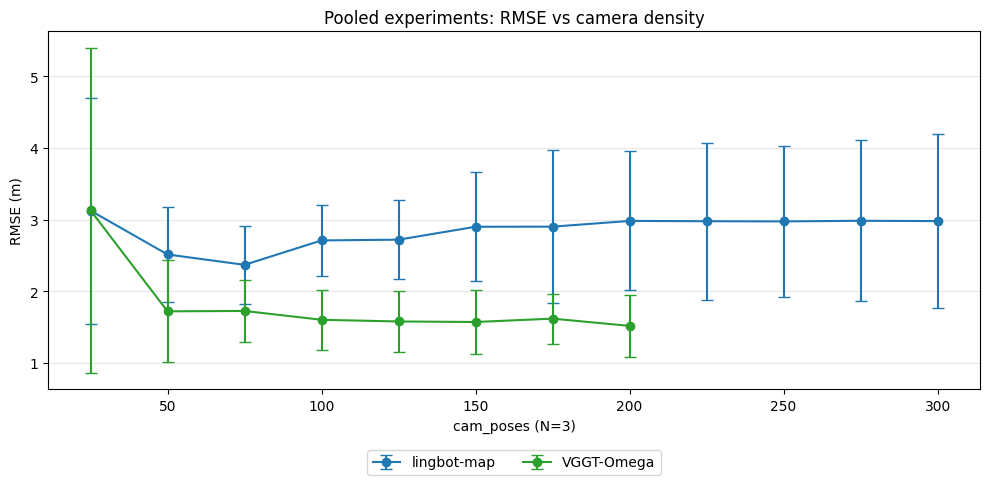

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)
from A_Config import set_case, case_dir
runs = [
    ("07_Tropea_cafe", "100m_gps_v3"),
    ("01_walk", "sweep_inferity"),
    ("01_walk", "sweeps_short_inferity"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"])["rmse"].agg(["mean", "std"]).reset_index()

#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.errorbar(
        sub["cam_poses"], sub["mean"], yerr=sub["std"],
        marker="o", markersize=6, capsize=4, label=technique, color=COLOR_MAP.get(technique),
    )

ax.set_xlabel("cam_poses (N=3)")
ax.set_ylabel("RMSE (m)")

ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(out_dir / "pooled_RMSE_density_precise_v_l.pdf", format="pdf", bbox_inches="tight")
fig.savefig(out_dir / "pooled_RMSE_density_precise_v_l.png", format="png", bbox_inches="tight")


## phone GPS

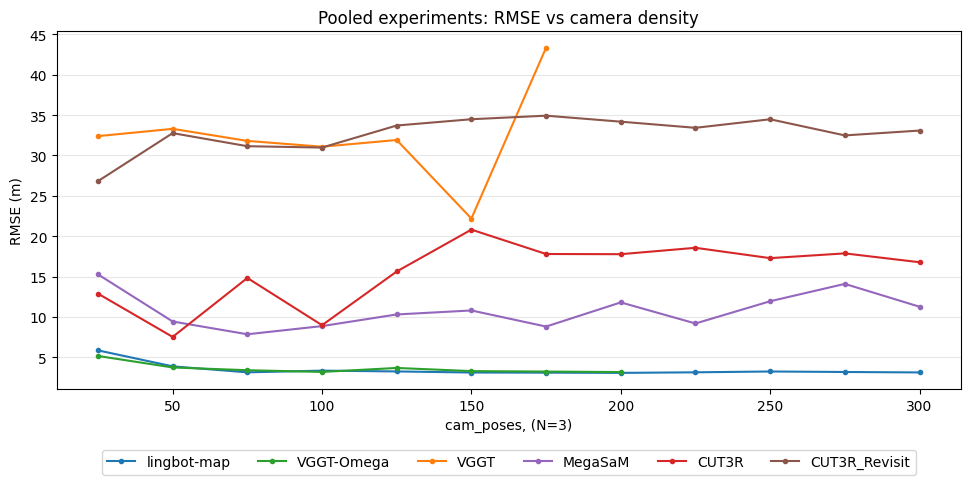

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Find the repo root by walking up until we hit src/A_Config.py -- see
# AA_Cam_pose_estimate_batches.ipynb for why this is more robust than Path.cwd().parent.
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
import sys
sys.path.insert(0, str(project_root / "src"))
from A_Config import set_case , case_dir
runs = [
    ("401_Hide_n_seek", "Cam_pose_v01"),
    ("11_walk_home_1", "Cam_pose_v03"),
    ("12_walk_home_2", "Cam_pose_v2"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"], as_index=False)[["rmse", "mean dist"]].mean()

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.plot(sub["cam_poses"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))



ax.set_xlabel("cam_poses, (N=3)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_density_coarse.pdf", format="pdf", bbox_inches="tight")


project_root: /workspace/project


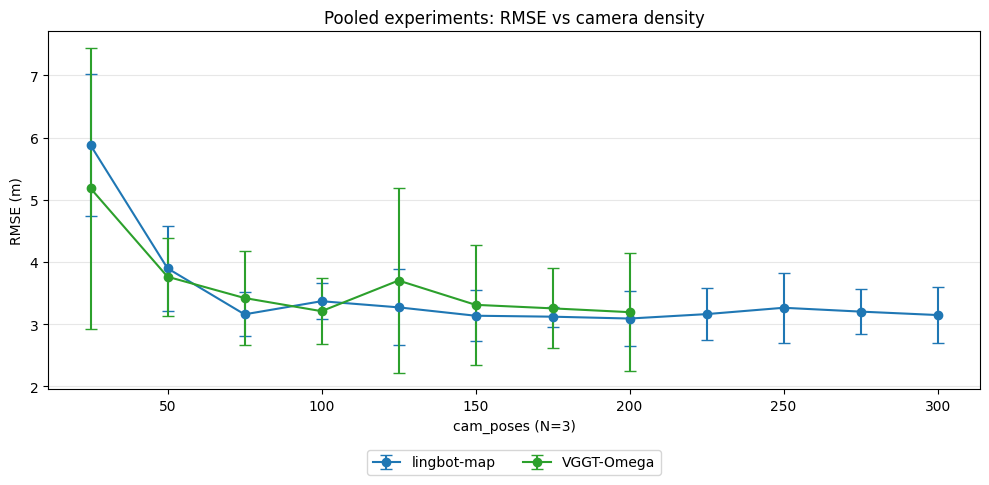

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
project_root = Path.cwd()
while not (project_root / "src" / "A_Config.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("couldn't find repo root (src/A_Config.py) above cwd")
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))
sys.path.insert(0, str(project_root / "Experiments" / "templates"))
print("project_root:", project_root)
from A_Config import set_case, case_dir
runs = [
    ("401_Hide_n_seek", "Cam_pose_v01"),
    ("11_walk_home_1", "Cam_pose_v03"),
    ("12_walk_home_2", "Cam_pose_v2"),
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "cam_poses"])["rmse"].agg(["mean", "std"]).reset_index()

#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("cam_poses")
    ax.errorbar(
        sub["cam_poses"], sub["mean"], yerr=sub["std"],
        marker="o", markersize=6, capsize=4, label=technique, color=COLOR_MAP.get(technique),
    )

ax.set_xlabel("cam_poses (N=3)")
ax.set_ylabel("RMSE (m)")

ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

fig.savefig(out_dir / "pooled_RMSE_density_coarse_v_l.pdf", format="pdf", bbox_inches="tight")
fig.savefig(out_dir / "pooled_RMSE_density_coarse_v_l.png", format="png", bbox_inches="tight")


# distance sweeps

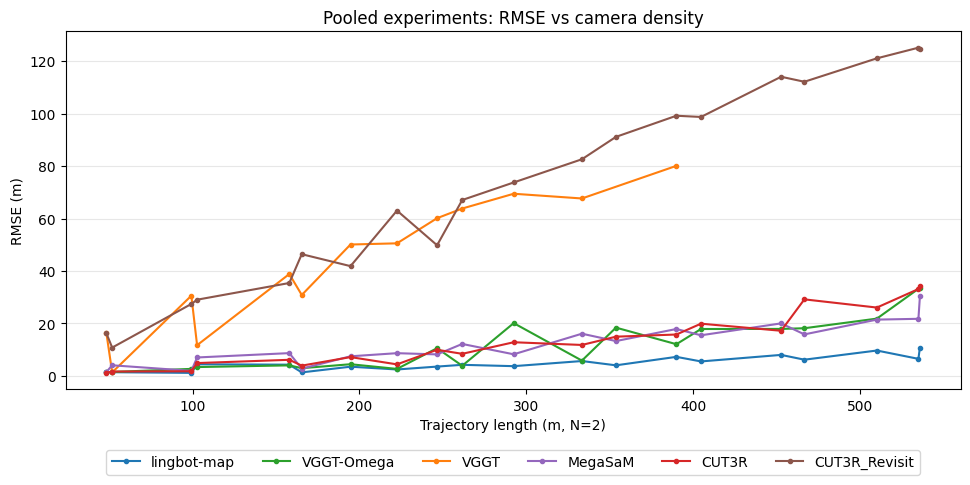

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

runs = [
    ("11_walk_home_1", "Cam_pose_v08_dist"),
    ("12_walk_home_2", "Cam_pose_dist_v6"),
    
]

dfs = []
for case, exp in runs:
    set_case(case)
    results_path = case_dir() / "080_Experiments" / exp / f"{exp}_results.csv"
    edf = pd.read_csv(results_path)
    dfs.append(edf)
df = pd.concat(dfs, ignore_index=True)

pooled = df.groupby(["technique", "trajectory length (m)"], as_index=False)[["rmse", "mean dist"]].mean()

TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega", "VGGT", "MegaSaM", "CUT3R", "CUT3R_Revisit"]
#TECHNIQUE_ORDER = ["lingbot-map", "VGGT-Omega"]
tab10 = plt.cm.tab10.colors
COLOR_MAP = {
    "lingbot-map": tab10[0],
    "VGGT":        tab10[1],
    "VGGT-Omega":  tab10[2],
    "CUT3R":       tab10[3],
    "MegaSaM":     tab10[4],
    "CUT3R_Revisit": tab10[5],
}

techniques = [t for t in TECHNIQUE_ORDER if t in pooled["technique"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))
for technique in techniques:
    sub = pooled[pooled["technique"] == technique].sort_values("trajectory length (m)")
    ax.plot(sub["trajectory length (m)"], sub["rmse"], marker="o", markersize=3, label=technique, color=COLOR_MAP.get(technique))



ax.set_xlabel("Trajectory length (m, N=2)")
ax.set_ylabel("RMSE (m)")
ax.set_title("Pooled experiments: RMSE vs camera density")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(techniques))

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "pooled_RMSE_distance_GPS.pdf", format="pdf", bbox_inches="tight")
fig.savefig(out_dir / "pooled_RMSE_distance_GPS.png", format="png", bbox_inches="tight")


In [22]:
from pathlib import Path

import pandas as pd

project_root = Path.cwd().resolve().parents[1]  # src/Experiments -> project root
out_dir = project_root / "Data" / "FIGS"

# Confidence percentiles, project-wide -- every case/recon-type/experiment/experiment_tag
# combination in Data/, produced by Thr3D/G_confidence_miner.py (re-run
# `python -m Thr3D.G_confidence_miner` from src/ to refresh). Not tied to any one
# case/run, unlike the sweep-results CSVs above -- see that module's docstring for what
# each recon type's confidence field actually is (and which ones don't have one at all).
conf_df = pd.read_csv(project_root / "Data" / "confidence_report.csv")
scored = conf_df[conf_df["confidence_available"]]
pct_cols = [c for c in conf_df.columns if c.startswith("p") and c[1:].isdigit()]
scored.groupby("recon_type")[["mean", *pct_cols]].describe()

mean                                                      \
               count       mean       std       min       25%        50%   
recon_type                                                                 
CUT3R          117.0   2.400621  0.687936  1.239012  1.911314   2.163016   
CUT3R_Revisit  112.0   1.645859  0.331796  1.087249  1.442641   1.593493   
MegaSaM         60.0   0.697936  0.239993  0.339658  0.480063   0.735704   
VGGT-O         130.0  13.263488  5.363873  1.218965  9.943044  13.050017   
lingbot-map    127.0   9.885063  3.599814  2.208840  8.160515   9.605098   

                                        p1            ...        p95  \
                     75%        max  count      mean  ...        75%   
recon_type                                            ...              
CUT3R           2.963343   4.158896  117.0  1.000000  ...   7.223115   
CUT3R_Revisit   1.800996   3.027462  112.0  1.000000  ...   3.812523   
MegaSaM         0.872502   1.144140   60.0  0.022143  ...   2.550293   
VGGT-O         17.716865  21.769519  130.0  1.033898  ...  42.526909   
lingbot-map    11.982341  23.815516  127.0  1.000000  ...  33.028846   

                            p99                                             \
                     max  count       mean        std       min        25%   
recon_type                                                                   
CUT3R          10.198790  117.0   7.871569   2.785434  3.472646   5.588134   
CUT3R_Revisit   6.828088  112.0   4.264040   1.064290  2.188706   3.411638   
MegaSaM         2.816406   60.0   2.473145   0.571259  0.500000   2.477539   
VGGT-O         53.267043  130.0  43.879698  21.021912  2.316169  30.338527   
lingbot-map    61.705269  127.0  41.292526  15.305000  6.502617  35.409573   

                                                
                     50%        75%        max  
recon_type                                      
CUT3R           7.258194  10.179049  16.310903  
CUT3R_Revisit   4.278927   4.770545   8.223617  
MegaSaM         2.628906   2.783691   2.970703  
VGGT-O         38.462465  64.865348  83.854820  
lingbot-map    41.101092  49.499219  98.504853  

[5 rows x 64 columns]

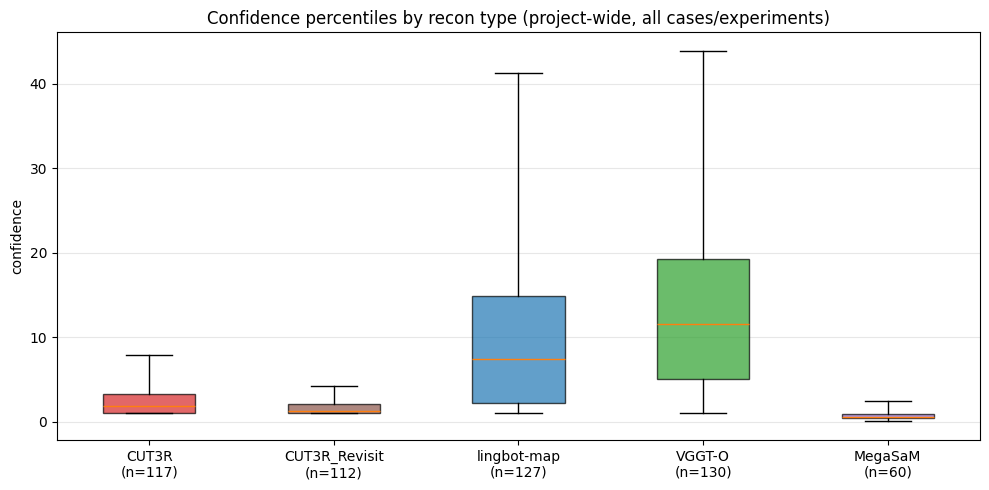

In [23]:
import matplotlib.pyplot as plt

# Boxplot per recon_type, built from each run's own percentile columns (no raw samples
# are stored in the CSV -- see miner docstring) rather than a real per-sample boxplot:
# whiskers = mean(p1)/mean(p99) across runs of that type, box = mean(p25)/mean(p50)/mean(p75).
# Same tab10 colour convention as the RMSE charts above.
RECON_TYPE_ORDER = ["CUT3R", "CUT3R_Revisit", "lingbot-map", "VGGT-O", "MegaSaM", "VGGT"]
tab10 = plt.cm.tab10.colors
CONF_COLOR_MAP = {
    "lingbot-map":   tab10[0],
    "VGGT":          tab10[1],
    "VGGT-O":        tab10[2],
    "CUT3R":         tab10[3],
    "MegaSaM":       tab10[4],
    "CUT3R_Revisit": tab10[5],
}

types_present = [t for t in RECON_TYPE_ORDER if t in scored["recon_type"].unique()]
stats = []
for t in types_present:
    sub = scored[scored["recon_type"] == t]
    stats.append({
        "label": f"{t}\n(n={len(sub)})",
        "whislo": sub["p1"].mean(),
        "q1":     sub["p25"].mean(),
        "med":    sub["p50"].mean(),
        "q3":     sub["p75"].mean(),
        "whishi": sub["p99"].mean(),
        "fliers": [],
    })

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.bxp(stats, showfliers=False, patch_artist=True, widths=0.5)
for patch, t in zip(bp["boxes"], types_present):
    patch.set_facecolor(CONF_COLOR_MAP.get(t, "gray"))
    patch.set_alpha(0.7)

ax.set_ylabel("confidence")
ax.set_title("Confidence percentiles by recon type (project-wide, all cases/experiments)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(out_dir / "confidence_by_recon_type.pdf", format="pdf", bbox_inches="tight")

# AUDIO CUT

/tmp/ipykernel_163881/265003121.py:132: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


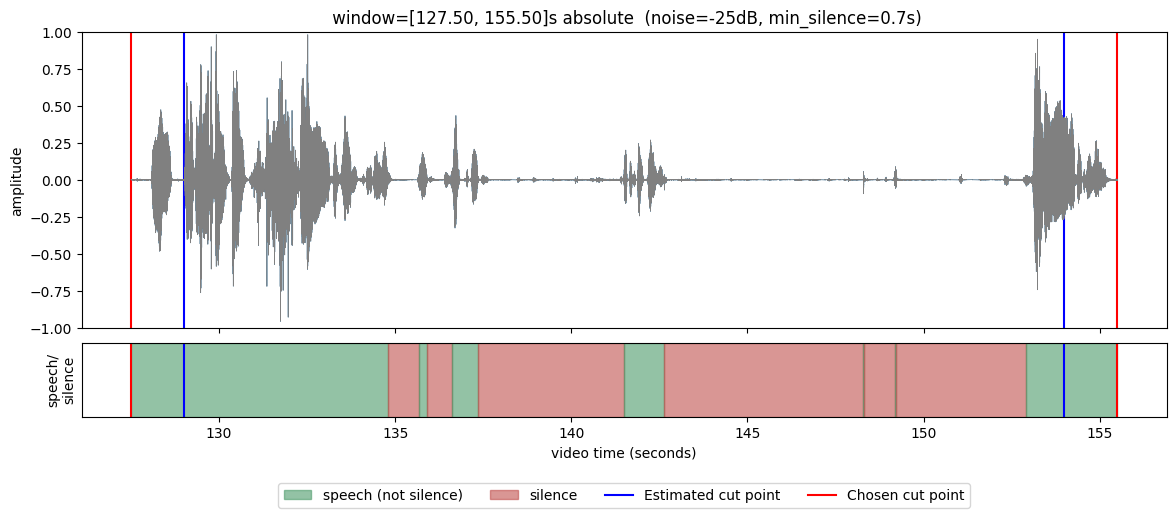

In [4]:
import re
from pathlib import Path
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import sys
project_root = Path.cwd().resolve().parents[1]  # src/Experiments -> project root
sys.path.insert(0, str(project_root / "src"))  # only path this notebook sets; A_Config adds the rest on import
from pathlib import Path
import importlib, Two2D.W_video_editor
importlib.reload(Two2D.W_video_editor)
from Two2D.W_video_editor import find_true_audio_span


from A_Config import (
    set_case, case_dir, source_dir, query_dir, sam3_masks_dir,
    frames_for_cam_poses_dir, frames_for_recon_dir, vggt_o_output_dir,
    predictions_path, ply_dir, reg_dir, csv_path_gps, csv_path_pose,
    assets_dir, recon_for_MAP_dir,recon_for_EVENT_dir, agent_p_output_dir,
    set_pass, pass_num
)



case_name = "402_Hide_n_seek_sw07"

set_case(case_name)

from Two2D.W_video_editor import find_true_audio_span

def plot_audio_cut_analysis(video_path, window_start_s, window_end_s,
                             noise_db=-25, min_silence_s=0.6, analysis_margin_s=1.5, handle_s=0.5):
    '''Reproduces find_true_audio_span's decision visually: waveform + speech/silence
    strip over the same absolute range it scans, with the chosen handle_in/handle_out
    cut points marked -- everything outside [onset, offset] is fair game, silencedetect
    just tells us it's SAFE to cut there.'''
    onset, offset, handle_in, handle_out = find_true_audio_span(
        video_path, window_start_s, window_end_s,
        analysis_margin_s=analysis_margin_s, noise_db=noise_db, min_silence_s=min_silence_s,
        handle_s=handle_s,
    )

    plot_lo = max(0.0, window_start_s - analysis_margin_s)
    plot_hi = window_end_s + analysis_margin_s

    # waveform: decode the plotted range to mono PCM16 via ffmpeg
    # waveform
    sr = 16000
    raw = subprocess.run(
        ["ffmpeg", "-i", str(video_path), "-vn",
         "-af", f"atrim=start={plot_lo}:end={plot_hi},asetpts=PTS-STARTPTS",
         "-ac", "1", "-ar", str(sr), "-f", "s16le", "-"],
        capture_output=True,
    ).stdout

    wav = np.frombuffer(raw, dtype=np.int16).astype(np.float32) / 32768.0
    t = np.linspace(plot_lo, plot_hi, num=len(wav), endpoint=False)


       # silence detect
    stderr = subprocess.run(
        ["ffmpeg", "-i", str(video_path), "-vn",
         "-af", f"atrim=start={plot_lo}:end={plot_hi},asetpts=PTS-STARTPTS,"
                f"silencedetect=noise={noise_db}dB:d={min_silence_s}",
         "-f", "null", "-"],
        capture_output=True, text=True,
    ).stderr

    starts = [float(m) for m in re.findall(r"silence_start:\s*([0-9.]+)", stderr)]
    ends   = [float(m) for m in re.findall(r"silence_end:\s*([0-9.]+)\s*\|", stderr)]
    if len(starts) > len(ends):
        ends.append(plot_hi - plot_lo)
    silences = [(plot_lo + s, plot_lo + e) for s, e in zip(starts, ends)]

    #charts
    fig, (ax_wav, ax_strip) = plt.subplots(
        2, 1, figsize=(14, 5), sharex=True, height_ratios=[4, 1],
        gridspec_kw={"hspace": 0.08},
    )

    ax_wav.plot(t, wav, linewidth=0.4)
    ax_wav.set_ylim(-1, 1)
    ax_wav.set_ylabel("amplitude")
    ax_wav.set_title(
        f" window=[{plot_lo:.2f}, {plot_hi:.2f}]s absolute  "
        f"(noise={noise_db}dB, min_silence={min_silence_s}s)"
    )

    cut_points = [handle_in, handle_out]
    for x in cut_points:
        ax_wav.axvline(x, color="red", linewidth=1.5)
    
    producer_points = [window_start_s, window_end_s]
    for x in producer_points:
        ax_wav.axvline(x, color="blue", linewidth=1.5)

    
    # speech/silence strip
    ax_strip.set_ylim(0, 1)
    ax_strip.set_yticks([])
    prev_end = plot_lo
    for s, e in silences:
        if s > prev_end:
            ax_strip.axvspan(prev_end, s, color="#4c9a6a", alpha=0.6)
        ax_strip.axvspan(s, e, color="#c0504d", alpha=0.6)
        prev_end = e
    if prev_end < plot_hi:
        ax_strip.axvspan(prev_end, plot_hi, color="#4c9a6a", alpha=0.6)
    for x in cut_points:
        ax_strip.axvline(x, color="red", linewidth=1.5)
    for x in producer_points:
        ax_strip.axvline(x, color="blue", linewidth=1.5)


    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    ax_strip.legend(
        handles=[
            Patch(color="#4c9a6a", alpha=0.6, label="speech (not silence)"),
            Patch(color="#c0504d", alpha=0.6, label="silence"),
            Line2D([0], [0], color="blue", linewidth=1.5, label="Estimated cut point"),
            Line2D([0], [0], color="red", linewidth=1.5, label="Chosen cut point"),
            
        ],
                loc="upper center", bbox_to_anchor=(0.5, -0.8), fontsize=10, ncol=4,

    )
    ax_strip.set_ylabel("speech/\nsilence")
    ax_strip.set_xlabel(f"video time (seconds)")
    ax_wav.plot(t, wav, linewidth=0.4, color="grey")
    
    fig.tight_layout()
    return fig

# --- example ---
video_path = case_dir() / "010_source" / "your_video.mp4"
video_path = next(source_dir().glob("*.mp4"))

fig = plot_audio_cut_analysis(video_path, window_start_s=129, window_end_s=154
                                                           
                            , min_silence_s = .7)

fig.savefig(out_dir / "Audiocuts.pdf", format="pdf", bbox_inches="tight")


In [7]:
print(find_true_audio_span(video_path, 82, 97,
                           noise_db=-30, min_silence_s=0.7))


off 97.488667
(82.741479, 100, 82.241479, 100)
